In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [5]:
df = pd.read_csv('data_science_job.csv',usecols=[2,8,11,12])

In [6]:
df.head()

,city_development_index,experience,training_hours,target
0,0.920,20.0,36.0,1.0
1,0.776,15.0,47.0,0.0
2,0.624,5.0,83.0,0.0
3,0.789,0.0,52.0,1.0
4,0.767,20.0,8.0,0.0


In [7]:
df.isnull().mean()*100

city_development_index    2.500261
experience                0.339284
training_hours            3.998330
target                    0.000000
dtype: float64

In [9]:
x = df.drop(columns=['target'])
y = df['target']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [16]:
x_train['city_development_index_99'] = x_train['city_development_index'].fillna(99)
x_train['city_development_index_minus1'] = x_train['city_development_index'].fillna(-1)

x_train['experience_99'] = x_train['experience'].fillna(99)
x_train['experience_minus1'] = x_train['experience'].fillna(-1)

x_train['training_hours_99'] = x_train['training_hours'].fillna(99)
x_train['training_hours_minus1'] = x_train['training_hours'].fillna(-1)

In [18]:
print("original city_development_index Column Variance", x_train['city_development_index'].var())
print("city_development_index Column Variance After 99 one Imputation", x_train['city_development_index_99'].var())
print("city_development_index Column Variance After minus1  Imputation", x_train['city_development_index_minus1'].var())
print("")
print("original experience Column Variance", x_train['experience'].var())
print("experience Column Variance After 99 Imputation", x_train['experience_99'].var())
print("experience Column Variance After -1 Imputation", x_train['experience_minus1'].var())
print("")
print("original training_hours Column Variance", x_train['training_hours'].var())
print("training_hours Column Variance After 99 Imputation", x_train['training_hours_99'].var())
print("training_hours Column Variance After -1 Imputation", x_train['training_hours_minus1'].var())

original city_development_index Column Variance 0.015232596622262501
city_development_index Column Variance After 99 one Imputation 239.63426160053768
city_development_index Column Variance After minus1  Imputation 0.0979867244706395

original experience Column Variance 42.31272262041923
experience Column Variance After 99 Imputation 67.45441036875738
experience Column Variance After -1 Imputation 42.55920642804021

original training_hours Column Variance 3605.7523453683752
training_hours Column Variance After 99 Imputation 3505.990888294398
training_hours Column Variance After -1 Imputation 3629.5315560523654


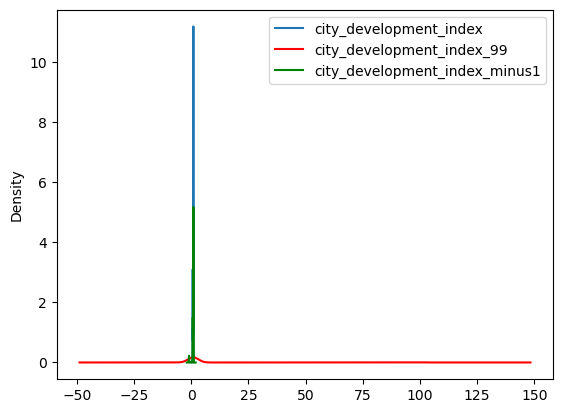

In [19]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['city_development_index'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['city_development_index_99'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['city_development_index_minus1'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

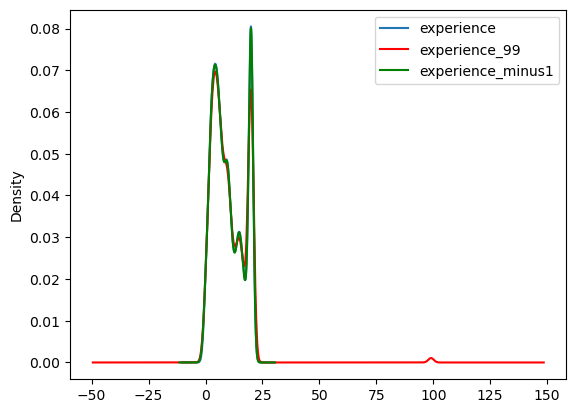

In [20]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['experience'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['experience_99'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['experience_minus1'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

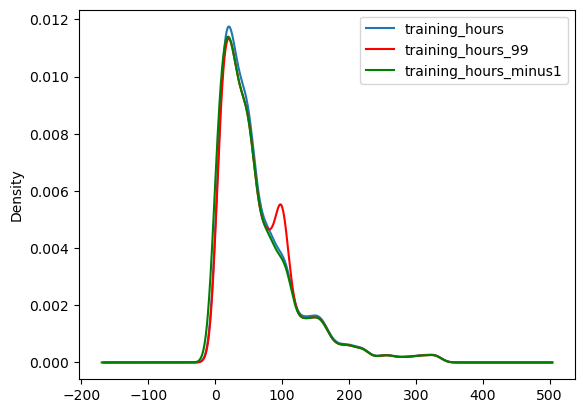

In [21]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['training_hours'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['training_hours_99'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['training_hours_minus1'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [22]:
x_train.cov()

,city_development_index,experience,training_hours,city_development_index_99,median_city_development_minus1,experience_99,experience_minus1,training_hours_99,training_hours_minus1,city_development_minus1,city_development_index_minus1
city_development_index,0.015233,0.265945,0.045247,0.015233,0.015233,0.246434,0.267382,0.031639,0.066558,0.015233,0.015233
experience,0.265945,42.312723,0.923956,0.815672,0.248788,42.312723,42.312723,0.496138,1.650073,0.248788,0.248788
training_hours,0.045247,0.923956,3605.752345,-6.330414,0.162842,4.861686,0.436040,3605.752345,3605.752345,0.162842,0.162842
city_development_index_99,0.015233,0.815672,-6.330414,239.634262,-4.448633,0.652208,0.832832,-7.078935,-4.122224,-4.448633,-4.448633
median_city_development_minus1,0.015233,0.248788,0.162842,-4.448633,0.097987,0.232471,0.249900,0.163268,0.142854,0.097987,0.097987
experience_99,0.246434,42.312723,4.861686,0.652208,0.232471,67.454410,39.070972,4.092087,5.794552,0.232471,0.232471
experience_minus1,0.267382,42.312723,0.436040,0.832832,0.249900,39.070972,42.559206,0.052426,1.134806,0.249900,0.249900
training_hours_99,0.031639,0.496138,3605.752345,-7.078935,0.163268,4.092087,0.052426,3505.990888,3376.661386,0.163268,0.163268
training_hours_minus1,0.066558,1.650073,3605.752345,-4.122224,0.142854,5.794552,1.134806,3376.661386,3629.531556,0.142854,0.142854
city_development_minus1,0.015233,0.248788,0.162842,-4.448633,0.097987,0.232471,0.249900,0.163268,0.142854,0.097987,0.097987


In [23]:
x_train.corr()

,city_development_index,experience,training_hours,city_development_index_99,median_city_development_minus1,experience_99,experience_minus1,training_hours_99,training_hours_minus1,city_development_minus1,city_development_index_minus1
city_development_index,1.000000,0.331741,0.006114,1.000000,1.000000,0.242961,0.332275,0.004327,0.008944,1.000000,1.000000
experience,0.331741,1.000000,0.002366,0.008098,0.122155,1.000000,1.000000,0.001289,0.004212,0.122155,0.122155
training_hours,0.006114,0.002366,1.000000,-0.006770,0.008622,0.009819,0.001113,1.000000,1.000000,0.008622,0.008622
city_development_index_99,1.000000,0.008098,-0.006770,1.000000,-0.918054,0.005130,0.008247,-0.007723,-0.004420,-0.918054,-0.918054
median_city_development_minus1,1.000000,0.122155,0.008622,-0.918054,1.000000,0.090423,0.122373,0.008809,0.007575,1.000000,1.000000
experience_99,0.242961,1.000000,0.009819,0.005130,0.090423,1.000000,0.729209,0.008415,0.011711,0.090423,0.090423
experience_minus1,0.332275,1.000000,0.001113,0.008247,0.122373,0.729209,1.000000,0.000136,0.002887,0.122373,0.122373
training_hours_99,0.004327,0.001289,1.000000,-0.007723,0.008809,0.008415,0.000136,1.000000,0.946579,0.008809,0.008809
training_hours_minus1,0.008944,0.004212,1.000000,-0.004420,0.007575,0.011711,0.002887,0.946579,1.000000,0.007575,0.007575
city_development_minus1,1.000000,0.122155,0.008622,-0.918054,1.000000,0.090423,0.122373,0.008809,0.007575,1.000000,1.000000


<Axes: >

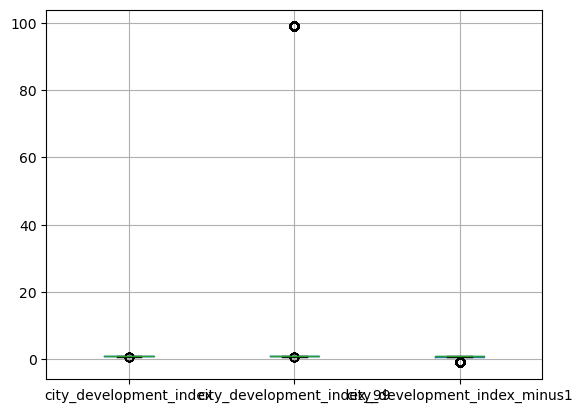

In [24]:
x_train[['city_development_index','city_development_index_99','city_development_index_minus1']].boxplot()

<Axes: >

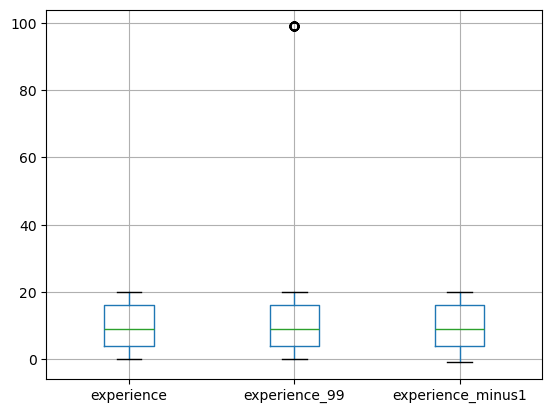

In [25]:
x_train[['experience','experience_99','experience_minus1']].boxplot()

<Axes: >

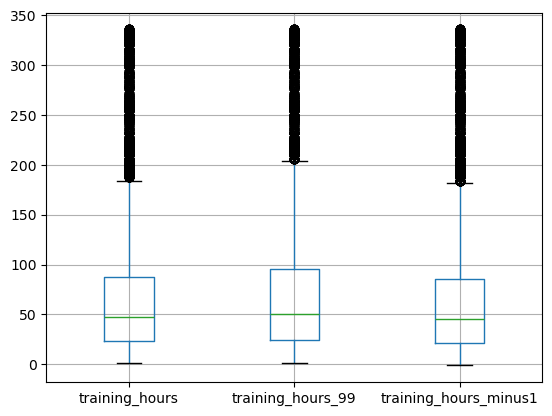

In [26]:
x_train[['training_hours','training_hours_99','training_hours_minus1']].boxplot()

In [27]:
# using Scikit Learn

In [28]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [29]:
imputer1 = SimpleImputer(strategy='constant', fill_value=99)
imputer2 = SimpleImputer(strategy='constant', fill_value=-1)

In [31]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['city_development_index']),
    ('imputer2',imputer2,['experience']),
    ('imputer3',imputer2,['training_hours'])
],remainder='passthrough')

In [32]:
trf.fit(x_train)

x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

x_train

array([[  0.624,   2.   , 134.   ],
       [  0.92 ,   8.   ,  58.   ],
       [  0.92 ,   7.   , 206.   ],
       ...,
       [  0.92 ,  20.   , 120.   ],
       [  0.92 ,   7.   ,  48.   ],
       [  0.91 ,   4.   ,  74.   ]])

In [33]:
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [34]:
trf.named_transformers_['imputer2'].statistics_

array([-1.])